# 🦟 AI-lerta — Sistema de Alerta Temprana Dengue Colombia
## Modelo de Clasificación basado en Canal Endémico Municipal

| Conjunto | Años | Propósito |
|---|---|---|
| **TRAIN** | 2009–2016 | Entrenamiento |
| **VALIDATION** | 2017–2019 | Ajuste de hiperparámetros |
| **TEST** | 2022–2024 | Evaluación final — no tocar hasta el final |

**Variable objetivo:** `alerta=1` si casos ≥ P75 histórico por municipio/semana epidemiológica

**Métrica principal:** F2-score (penaliza falsos negativos 2x más que falsos positivos)

**Justificación:** En dengue, el costo de una falsa alarma (fumigación preventiva) es menor
que el costo de un brote no detectado. Se prioriza recall sobre precisión.
(Chan & Johansson, 2012; Mordecai et al., 2017)

## Paso 1 — Importar librerías y cargar datos

In [1]:
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (fbeta_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              classification_report,
                              precision_recall_fscore_support)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset completo
gdown.download('https://drive.google.com/uc?id=1S76FGFaw6Sywj-sfOWcl6UqOCsbb1M2i',
               'dataset_dengue_completo.csv', quiet=False)

df = pd.read_csv('dataset_dengue_completo.csv')
df['cod_municipio'] = df['cod_municipio'].astype(str).str.zfill(5)
print(f'Dataset cargado: {len(df):,} filas')
print(f'Años: {sorted(df["anio"].unique())}')
print(f'Columnas: {df.columns.tolist()}')

Downloading...
From: https://drive.google.com/uc?id=1S76FGFaw6Sywj-sfOWcl6UqOCsbb1M2i
To: /Users/sebastian/Documents/Juan_Sebastian/MAIA/proyecto_grado/Untitled/Proyecto-Despliegue_de_soluciones-Team-24/dataset_dengue_completo.csv
100%|██████████████████████████████████████| 42.9M/42.9M [00:01<00:00, 42.4MB/s]


Dataset cargado: 257,482 filas
Años: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024]
Columnas: ['cod_municipio', 'anio', 'semana_epi', 'tipo_dengue', 'casos', 'NOM_MPIO', 'NOM_DPTO', 'altitud_msnm', 'cat_altitud', 'split', 'poblacion', 'tasa_x100k', 'temp_media_c', 'humedad_pct', 'precip_mm', 'temp_lag2', 'precip_lag2', 'temp_lag3', 'precip_lag3', 'temp_lag4', 'precip_lag4', 'humedad_lag1', 'humedad_lag2', 'humedad_lag3']


## Paso 2 — Agregar a nivel municipal (colapsar tipo_dengue)

In [2]:
COLS_CLIMA = ['temp_media_c','humedad_pct','precip_mm',
              'temp_lag2','temp_lag3','temp_lag4',
              'precip_lag2','precip_lag3','precip_lag4',
              'humedad_lag1','humedad_lag2','humedad_lag3']

# Colapsar tipo_dengue sumando casos por municipio+semana
df_mun = (df.groupby(['cod_municipio','NOM_MPIO','NOM_DPTO',
                       'anio','semana_epi','altitud_msnm',
                       'cat_altitud','poblacion'] + COLS_CLIMA)
          .agg(casos=('casos','sum'))
          .reset_index()
)
df_mun['tasa_x100k'] = (df_mun['casos'] / df_mun['poblacion']) * 100000
df_mun['split'] = df_mun['anio'].apply(lambda x: 'train' if x <= 2019 else 'test')

print(f'Municipal colapsado: {len(df_mun):,} filas')
print(f'Municipios únicos  : {df_mun["cod_municipio"].nunique()}')
print(f'Años               : {sorted(df_mun["anio"].unique())}')

Municipal colapsado: 152,611 filas
Municipios únicos  : 940
Años               : [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024]


## Paso 3 — Identificar municipios válidos para canal endémico

In [3]:
# Municipios con >= 20 semanas con casos en el período de entrenamiento (2009-2016)
# Necesitamos suficiente historia para calcular percentiles confiables
df_train_mun = df_mun[df_mun['anio'].isin(range(2009, 2017))].copy()

semanas_por_mun = df_train_mun[df_train_mun['casos'] > 0].groupby('cod_municipio').size()
municipios_validos = semanas_por_mun[semanas_por_mun >= 20].index

print(f'Municipios con >= 20 semanas con casos: {len(municipios_validos)}')
print(f'Municipios totales en train            : {df_train_mun["cod_municipio"].nunique()}')
print(f'Medellín (05001) válido: {"05001" in municipios_validos}')
print(f'Cali    (76001) válido: {"76001" in municipios_validos}')

Municipios con >= 20 semanas con casos: 651
Municipios totales en train            : 898
Medellín (05001) válido: True
Cali    (76001) válido: True


## Paso 4 — Construir grilla completa (incluye semanas con cero casos)

In [4]:
# Info fija por municipio
info_mun = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
            [['cod_municipio','NOM_MPIO','NOM_DPTO','altitud_msnm','cat_altitud']]
            .drop_duplicates('cod_municipio'))

# Grilla completa: todos los municipios x todos los años x semanas 1-52
años_train = list(range(2009, 2020))
años_test  = [2022, 2023, 2024]
todos_años = años_train + años_test

grilla = pd.MultiIndex.from_product(
    [municipios_validos, todos_años, range(1, 53)],
    names=['cod_municipio', 'anio', 'semana_epi']
).to_frame(index=False)

# Casos reales
casos_ref = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
             [['cod_municipio','anio','semana_epi','casos','tasa_x100k']]
             .drop_duplicates(['cod_municipio','anio','semana_epi']))

# Clima
clima_ref = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
             [['cod_municipio','anio','semana_epi'] + COLS_CLIMA]
             .drop_duplicates(['cod_municipio','anio','semana_epi']))

# Población
pob_ref = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
           .groupby(['cod_municipio','anio'])['poblacion'].first().reset_index())

# Unir todo
df_completo = grilla.copy()
df_completo = df_completo.merge(casos_ref, on=['cod_municipio','anio','semana_epi'], how='left')
df_completo['casos']      = df_completo['casos'].fillna(0)
df_completo['tasa_x100k'] = df_completo['tasa_x100k'].fillna(0)
df_completo = df_completo.merge(pob_ref,   on=['cod_municipio','anio'], how='left')
df_completo = df_completo.merge(clima_ref, on=['cod_municipio','anio','semana_epi'], how='left')
df_completo = df_completo.merge(info_mun,  on='cod_municipio', how='left')

# Interpolar clima
df_completo = df_completo.sort_values(['cod_municipio','anio','semana_epi'])
for col in COLS_CLIMA:
    df_completo[col] = (df_completo.groupby('cod_municipio')[col]
                        .transform(lambda x: x.interpolate().ffill().bfill()))

df_completo['split'] = df_completo['anio'].apply(
    lambda x: 'train' if x <= 2019 else 'test')

print(f'Grilla completa: {len(df_completo):,} filas')
print(f'Esperado: {len(municipios_validos)} x {len(todos_años)} x 52 = {len(municipios_validos)*len(todos_años)*52:,}')
print(f'Duplicados: {df_completo.duplicated(["cod_municipio","anio","semana_epi"]).sum()}')
print(f'Con casos: {(df_completo["casos"]>0).sum():,}')
print(f'Sin casos: {(df_completo["casos"]==0).sum():,}')

Grilla completa: 473,928 filas
Esperado: 651 x 14 x 52 = 473,928
Duplicados: 0
Con casos: 110,674
Sin casos: 363,254


## Paso 5 — Canal endémico municipal (P25/mediana/P75)

Calculado **solo con semanas que tuvieron casos** en el período de entrenamiento 2009-2016.
Los percentiles se aplican luego a todas las semanas — las semanas con 0 casos quedan en zona seguridad.

**Zonas del canal (INS Colombia):**
- 🔴 **Epidémica**: casos ≥ P75
- 🟡 **Alerta**: casos entre mediana y P75
- 🟢 **Éxito**: casos entre P25 y mediana
- 🔵 **Seguridad**: casos < P25

**Variable objetivo binaria:** ALERTA=1 (epidémica + alerta) vs NORMAL=0 (éxito + seguridad)

In [5]:
# Percentiles solo de semanas con casos en 2009-2016
df_train_completo = df_completo[df_completo['anio'].isin(range(2009, 2017))]
df_train_con_casos = df_train_completo[df_train_completo['casos'] > 0].copy()

canal_mun = (df_train_con_casos.groupby(['cod_municipio','semana_epi'])['casos']
             .agg(
                 p25    = lambda x: x.quantile(0.25),
                 mediana= lambda x: x.quantile(0.50),
                 p75    = lambda x: x.quantile(0.75),
             )
             .reset_index()
)

print(f'Canal endémico: {len(canal_mun):,} filas | {canal_mun["cod_municipio"].nunique()} municipios')
print('\nEjemplo Medellín semanas 1-5:')
print(canal_mun[canal_mun['cod_municipio']=='05001'].head(5).to_string())

Canal endémico: 23,434 filas | 651 municipios

Ejemplo Medellín semanas 1-5:
  cod_municipio  semana_epi   p25  mediana    p75
0         05001           1  4.00      5.0  64.00
1         05001           2  2.00      3.0   4.00
2         05001           3  4.00      4.0   4.00
3         05001           4  2.00      3.0  12.00
4         05001           5  6.25     10.5  14.75


## Paso 6 — Clasificar zonas del canal y crear variable objetivo

In [6]:
# Función de clasificación corregida
# Bug fix: P75=0 y casos=0 → seguridad (no epidémica)
def clasificar_zona_v2(row):
    if pd.isna(row['p25']):
        return 'seguridad'
    if row['p75'] == 0 and row['casos'] == 0:
        return 'seguridad'
    if row['p25'] == row['p75']:
        if row['casos'] > row['p75']: return 'epidemica'
        elif row['casos'] == row['p75'] and row['casos'] > 0: return 'alerta'
        elif row['casos'] == 0: return 'seguridad'
        else: return 'exito'
    if row['casos'] >= row['p75']:     return 'epidemica'
    elif row['casos'] >= row['mediana']: return 'alerta'
    elif row['casos'] >= row['p25']:     return 'exito'
    else:                                return 'seguridad'

df_modelo = df_completo.merge(canal_mun, on=['cod_municipio','semana_epi'], how='left')
df_modelo['p25']     = df_modelo['p25'].fillna(0)
df_modelo['mediana'] = df_modelo['mediana'].fillna(0)
df_modelo['p75']     = df_modelo['p75'].fillna(0)
df_modelo['zona_canal'] = df_modelo.apply(clasificar_zona_v2, axis=1)
df_modelo['alerta'] = df_modelo['zona_canal'].map({
    'epidemica': 1, 'alerta': 1, 'exito': 0, 'seguridad': 0
})

print('Distribución zonas:')
print(df_modelo['zona_canal'].value_counts())
print(f'\n% alerta global: {df_modelo["alerta"].mean()*100:.1f}%')

Distribución zonas:
zona_canal
seguridad    378901
alerta        42913
epidemica     39756
exito         12358
Name: count, dtype: int64

% alerta global: 17.4%


## Paso 7 — Variables autoregresivas y biológicas del vector

In [7]:
df_modelo_sorted = df_modelo.sort_values(['cod_municipio','anio','semana_epi']).copy()

# ── Autoregresivas ───────────────────────────────────────────────────────────
for lag in [1, 2, 3, 4]:
    df_modelo_sorted[f'casos_lag{lag}'] = (
        df_modelo_sorted.groupby('cod_municipio')['casos'].shift(lag))

df_modelo_sorted['casos_ma4'] = (
    df_modelo_sorted.groupby('cod_municipio')['casos']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()))

df_modelo_sorted['casos_tendencia'] = (
    df_modelo_sorted['casos_lag1'] - df_modelo_sorted['casos_lag2'])

# ── Variables biológicas (Mordecai et al. 2017, Chan & Johansson 2012) ────────
# Grados-día sobre 18°C (umbral mínimo desarrollo Aedes aegypti)
df_modelo_sorted['grados_dia'] = (df_modelo_sorted['temp_media_c'] - 18).clip(lower=0)

# Rango óptimo 26-29°C
df_modelo_sorted['temp_optima'] = (
    (df_modelo_sorted['temp_media_c'] >= 26) &
    (df_modelo_sorted['temp_media_c'] <= 29)).astype(int)

# Temperatura letal >35°C
df_modelo_sorted['temp_letal'] = (df_modelo_sorted['temp_media_c'] > 35).astype(int)

# Temperatura inhibición <16°C
df_modelo_sorted['temp_inhibicion'] = (df_modelo_sorted['temp_media_c'] < 16).astype(int)

# Precipitación acumulada 4 y 8 semanas
df_modelo_sorted['precip_acum4'] = (
    df_modelo_sorted.groupby('cod_municipio')['precip_mm']
    .transform(lambda x: x.rolling(4, min_periods=1).sum()))
df_modelo_sorted['precip_acum8'] = (
    df_modelo_sorted.groupby('cod_municipio')['precip_mm']
    .transform(lambda x: x.rolling(8, min_periods=1).sum()))

# Índice de idoneidad altitud x temperatura
df_modelo_sorted['indice_idoneidad'] = (
    df_modelo_sorted['temp_media_c'] *
    (1 / (1 + np.exp(0.003 * (df_modelo_sorted['altitud_msnm'] - 2200)))))

# Estacionalidad cíclica
df_modelo_sorted['semana_sin'] = np.sin(2 * np.pi * df_modelo_sorted['semana_epi'] / 52)
df_modelo_sorted['semana_cos'] = np.cos(2 * np.pi * df_modelo_sorted['semana_epi'] / 52)

# Temporadas de lluvias Colombia
df_modelo_sorted['temporada_lluvias'] = df_modelo_sorted['semana_epi'].apply(
    lambda s: 1 if (13 <= s <= 22) or (35 <= s <= 44) else 0)

# Años de brotes nacionales documentados
df_modelo_sorted['año_epidemico'] = df_modelo_sorted['anio'].isin(
    [2010, 2013, 2016, 2019]).astype(int)
df_modelo_sorted['post_epidemia'] = df_modelo_sorted['anio'].isin(
    [2011, 2014, 2017]).astype(int)

print('Variables creadas correctamente')
print(f'Shape: {df_modelo_sorted.shape}')

Variables creadas correctamente
Shape: (473928, 46)


## Paso 8 — Preparar features y dividir Train / Validation / Test

In [8]:
FEATURES_FINAL = [
    # Geografía
    'altitud_msnm', 'cat_altitud_enc',
    # Temporal
    'anio', 'semana_epi', 'semana_sin', 'semana_cos', 'temporada_lluvias',
    # Clima actual
    'temp_media_c', 'humedad_pct', 'precip_mm',
    # Variables biológicas temperatura
    'grados_dia', 'temp_optima', 'temp_letal', 'temp_inhibicion',
    # Índice idoneidad
    'indice_idoneidad',
    # Precipitación acumulada
    'precip_acum4', 'precip_acum8',
    # Rezagos clima
    'temp_lag2', 'temp_lag3', 'temp_lag4',
    'precip_lag2', 'precip_lag3', 'precip_lag4',
    'humedad_lag1', 'humedad_lag2', 'humedad_lag3',
    # Autoregresión
    'casos_lag1', 'casos_lag2', 'casos_lag3', 'casos_lag4',
    'casos_ma4', 'casos_tendencia',
    # Población y momentos históricos
    'poblacion', 'año_epidemico', 'post_epidemia',
]

# Codificar cat_altitud — fit SOLO con datos de train (2009-2016)
# Esto evita cualquier posible leakage de información del período de test
le = LabelEncoder()
categorias_train = (df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2009,2017))]
                    ['cat_altitud'].fillna('Sin dato').unique())
le.fit(categorias_train)
df_modelo_sorted['cat_altitud_enc'] = le.transform(
    df_modelo_sorted['cat_altitud'].fillna('Sin dato'))

# Dividir
df_tr  = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2009,2017))].copy()
df_val = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2017,2020))].copy()
df_te  = df_modelo_sorted[df_modelo_sorted['anio'].isin([2022,2023,2024])].copy()

df_tr_c  = df_tr.dropna(subset=FEATURES_FINAL + ['alerta']).copy()
df_val_c = df_val.dropna(subset=FEATURES_FINAL + ['alerta']).copy()
df_te_c  = df_te.dropna(subset=FEATURES_FINAL + ['alerta']).copy()

X_tr  = df_tr_c[FEATURES_FINAL];  y_tr  = df_tr_c['alerta'].astype(int)
X_val = df_val_c[FEATURES_FINAL]; y_val = df_val_c['alerta'].astype(int)
X_te  = df_te_c[FEATURES_FINAL];  y_te  = df_te_c['alerta'].astype(int)

print(f'TRAIN      : {len(X_tr):,} | alerta: {y_tr.mean()*100:.1f}%')
print(f'VALIDATION : {len(X_val):,} | alerta: {y_val.mean()*100:.1f}%')
print(f'TEST       : {len(X_te):,} | alerta: {y_te.mean()*100:.1f}%')
print(f'Features   : {len(FEATURES_FINAL)}')

TRAIN      : 225,492 | alerta: 20.7%
VALIDATION : 82,628 | alerta: 15.7%
TEST       : 91,364 | alerta: 25.3%
Features   : 35


## Paso 9 — Entrenar y comparar modelos en Validation

In [9]:
UMBRAL = 0.5

modelos = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight={0:1, 1:5}, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=5,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0),
}

resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    print(f'Entrenando {nombre}...')
    modelo.fit(X_tr, y_tr)
    modelos_entrenados[nombre] = modelo
    y_prob = modelo.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= UMBRAL).astype(int)
    resultados.append({
        'Modelo'    : nombre,
        'Precision' : round(precision_score(y_val, y_pred, zero_division=0), 3),
        'Recall'    : round(recall_score(y_val, y_pred, zero_division=0), 3),
        'F2'        : round(fbeta_score(y_val, y_pred, beta=2, zero_division=0), 3),
        'AUC'       : round(roc_auc_score(y_val, y_prob), 3),
        '% Alertas' : round(y_pred.mean()*100, 1),
    })
    print(f'  F2={resultados[-1]["F2"]} | AUC={resultados[-1]["AUC"]} | '
          f'Recall={resultados[-1]["Recall"]} | Precision={resultados[-1]["Precision"]}')

print('\n=== COMPARACIÓN VALIDATION ===')
print(pd.DataFrame(resultados).sort_values('F2', ascending=False).to_string(index=False))

Entrenando Random Forest...
  F2=0.648 | AUC=0.846 | Recall=0.776 | Precision=0.389
Entrenando XGBoost...
  F2=0.678 | AUC=0.868 | Recall=0.805 | Precision=0.416

=== COMPARACIÓN VALIDATION ===
       Modelo  Precision  Recall    F2   AUC  % Alertas
      XGBoost      0.416   0.805 0.678 0.868       30.5
Random Forest      0.389   0.776 0.648 0.846       31.3


## Paso 10 — Umbral óptimo y evaluación completa del mejor modelo

Umbral óptimo (max F2): 0.5
 umbral  precision  recall    f2
   0.10      0.171   0.995 0.507
   0.15      0.192   0.983 0.539
   0.20      0.231   0.956 0.587
   0.25      0.271   0.926 0.624
   0.30      0.303   0.900 0.646
   0.35      0.333   0.875 0.660
   0.40      0.361   0.851 0.669
   0.45      0.388   0.829 0.675
   0.50      0.416   0.805 0.678
   0.55      0.445   0.779 0.677
   0.60      0.475   0.747 0.670
   0.65      0.504   0.708 0.655
   0.70      0.535   0.660 0.631
   0.75      0.572   0.595 0.590
   0.80      0.611   0.515 0.531
   0.85      0.664   0.397 0.431


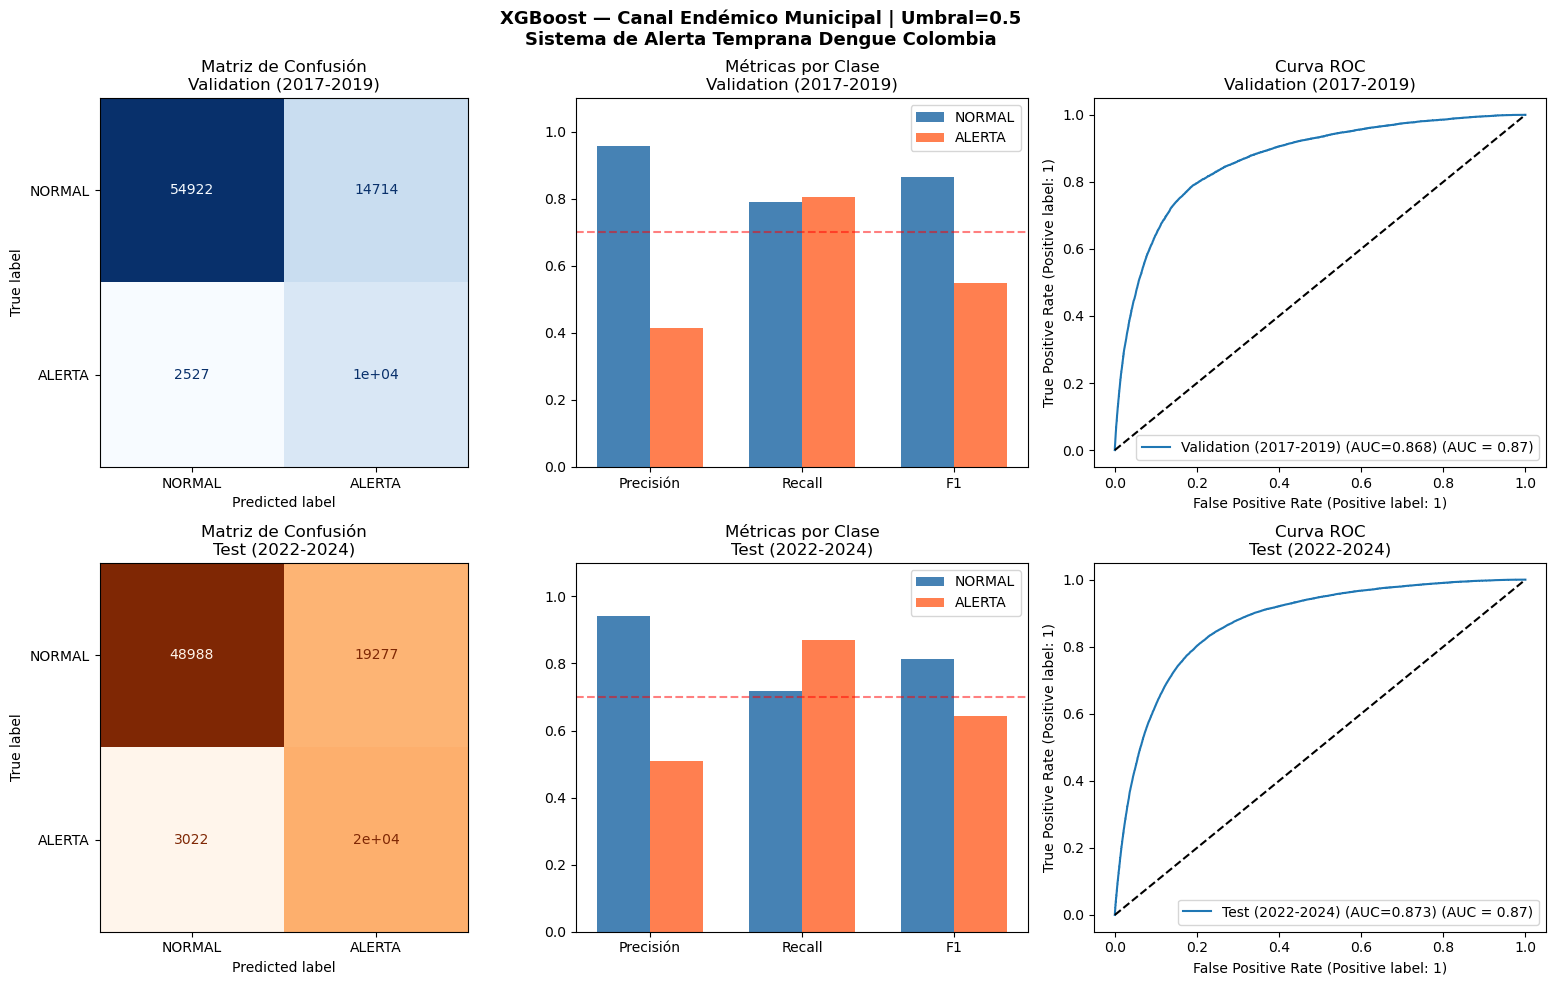


=== VALIDATION ===
              precision    recall  f1-score   support

      NORMAL      0.956     0.789     0.864     69636
      ALERTA      0.416     0.805     0.548     12992

    accuracy                          0.791     82628
   macro avg      0.686     0.797     0.706     82628
weighted avg      0.871     0.791     0.815     82628

F2-score : 0.678
AUC-ROC  : 0.868

=== TEST ===
              precision    recall  f1-score   support

      NORMAL      0.942     0.718     0.815     68265
      ALERTA      0.510     0.869     0.643     23099

    accuracy                          0.756     91364
   macro avg      0.726     0.793     0.729     91364
weighted avg      0.833     0.756     0.771     91364

F2-score : 0.762
AUC-ROC  : 0.873


In [10]:
# Usar el mejor modelo según F2 en validation
mejor_modelo = modelos_entrenados['XGBoost']

# Buscar umbral óptimo maximizando F2
y_prob_val = mejor_modelo.predict_proba(X_val)[:, 1]
res_u = []
for u in np.arange(0.1, 0.9, 0.05):
    yp = (y_prob_val >= u).astype(int)
    if yp.sum() == 0 or (1-yp).sum() == 0: continue
    res_u.append({
        'umbral'    : round(u, 2),
        'precision' : round(precision_score(y_val, yp, zero_division=0), 3),
        'recall'    : round(recall_score(y_val, yp, zero_division=0), 3),
        'f2'        : round(fbeta_score(y_val, yp, beta=2, zero_division=0), 3),
    })

df_u = pd.DataFrame(res_u)
UMBRAL_OPT = df_u.loc[df_u['f2'].idxmax(), 'umbral']
print(f'Umbral óptimo (max F2): {UMBRAL_OPT}')
print(df_u.to_string(index=False))

# Predicciones con umbral óptimo
y_pred_val = (y_prob_val >= UMBRAL_OPT).astype(int)
y_prob_te  = mejor_modelo.predict_proba(X_te)[:, 1]
y_pred_te  = (y_prob_te  >= UMBRAL_OPT).astype(int)

# Gráficas: matrices de confusión + métricas + curvas ROC
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'XGBoost — Canal Endémico Municipal | Umbral={UMBRAL_OPT}\n'
             'Sistema de Alerta Temprana Dengue Colombia',
             fontsize=13, fontweight='bold')

for fila, (y_r, y_p, y_pb, titulo, cmap) in enumerate([
    (y_val, y_pred_val, y_prob_val, 'Validation (2017-2019)', 'Blues'),
    (y_te,  y_pred_te,  y_prob_te,  'Test (2022-2024)',       'Oranges')
]):
    ConfusionMatrixDisplay(confusion_matrix(y_r, y_p),
                           display_labels=['NORMAL','ALERTA']).plot(
        ax=axes[fila,0], colorbar=False, cmap=cmap)
    axes[fila,0].set_title(f'Matriz de Confusión\n{titulo}')

    prec, rec, f1, _ = precision_recall_fscore_support(y_r, y_p)
    x = np.arange(3); w = 0.35
    axes[fila,1].bar(x-w/2, [prec[0],rec[0],f1[0]], w, label='NORMAL',  color='steelblue')
    axes[fila,1].bar(x+w/2, [prec[1],rec[1],f1[1]], w, label='ALERTA',  color='coral')
    axes[fila,1].set_xticks(x)
    axes[fila,1].set_xticklabels(['Precisión','Recall','F1'])
    axes[fila,1].set_ylim(0, 1.1)
    axes[fila,1].set_title(f'Métricas por Clase\n{titulo}')
    axes[fila,1].legend()
    axes[fila,1].axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Meta 0.7')

    RocCurveDisplay.from_predictions(
        y_r, y_pb, ax=axes[fila,2],
        name=f'{titulo} (AUC={roc_auc_score(y_r,y_pb):.3f})')
    axes[fila,2].plot([0,1],[0,1],'k--')
    axes[fila,2].set_title(f'Curva ROC\n{titulo}')

plt.tight_layout()
plt.savefig('xgb_evaluacion_completa.png', dpi=150, bbox_inches='tight')
plt.show()

# Reporte detallado
for nombre, y_r, y_p, y_pb in [
    ('VALIDATION', y_val, y_pred_val, y_prob_val),
    ('TEST',       y_te,  y_pred_te,  y_prob_te)
]:
    print(f'\n=== {nombre} ===')
    print(classification_report(y_r, y_p, target_names=['NORMAL','ALERTA'], digits=3))
    print(f'F2-score : {fbeta_score(y_r, y_p, beta=2):.3f}')
    print(f'AUC-ROC  : {roc_auc_score(y_r, y_pb):.3f}')

## Paso 11 — Importancia de variables

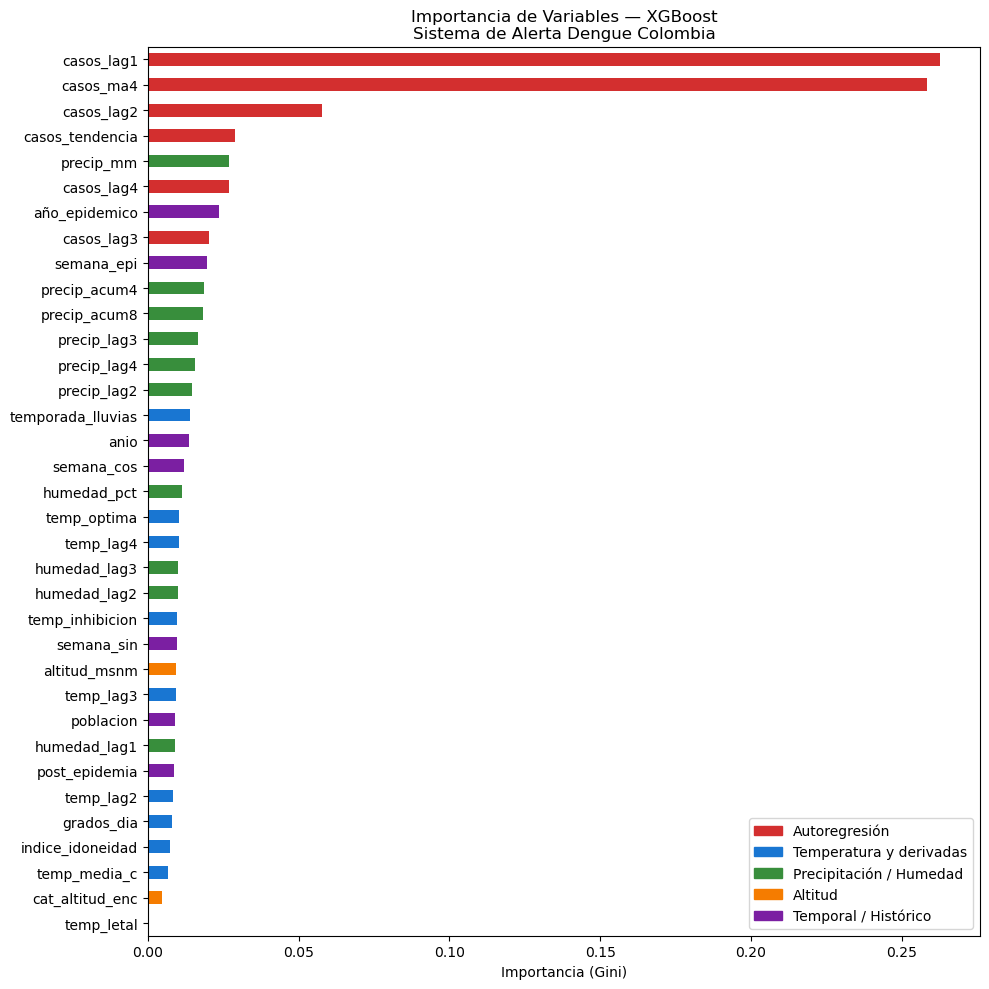

Top 10 variables más importantes:
casos_lag1         0.2628
casos_ma4          0.2584
casos_lag2         0.0576
casos_tendencia    0.0290
precip_mm          0.0269
casos_lag4         0.0268
año_epidemico      0.0236
casos_lag3         0.0204
semana_epi         0.0195
precip_acum4       0.0185


In [11]:
imp = pd.Series(mejor_modelo.feature_importances_, index=FEATURES_FINAL)

colores = ['#d32f2f' if 'casos' in v
           else '#1976d2' if any(x in v for x in ['temp','grados','optima','letal','inhib','idone'])
           else '#388e3c' if any(x in v for x in ['precip','humedad'])
           else '#f57c00' if any(x in v for x in ['altitud','cat_alt'])
           else '#7b1fa2'
           for v in imp.sort_values().index]

fig, ax = plt.subplots(figsize=(10, 10))
imp.sort_values().plot(kind='barh', ax=ax, color=colores)
ax.set_title('Importancia de Variables — XGBoost\nSistema de Alerta Dengue Colombia', fontsize=12)
ax.set_xlabel('Importancia (Gini)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d32f2f', label='Autoregresión'),
    Patch(color='#1976d2', label='Temperatura y derivadas'),
    Patch(color='#388e3c', label='Precipitación / Humedad'),
    Patch(color='#f57c00', label='Altitud'),
    Patch(color='#7b1fa2', label='Temporal / Histórico'),
], loc='lower right')

plt.tight_layout()
plt.savefig('xgb_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 variables más importantes:')
print(imp.nlargest(10).round(4).to_string())

## Paso 12 — Clasificación multiclase: 4 zonas del canal endémico

Distribución clases TRAIN:
  0 - seguridad   : 172,756 (76.6%)
  1 - exito       : 6,164 (2.7%)
  2 - alerta      : 30,496 (13.5%)
  3 - epidemica   : 16,076 (7.1%)

Pesos de clase: {0: 0.32631572854198987, 2: 1.8485375131164743, 1: 9.145522388059701, 3: 3.5066558845483953}

Entrenando XGBoost multiclase...
✅ Modelo entrenado

=== VALIDATION (2017-2019) ===
              precision    recall  f1-score   support

   Seguridad      0.946     0.794     0.864     66826
       Éxito      0.117     0.513     0.191      2810
      Alerta      0.156     0.293     0.203      5208
   Epidémica      0.509     0.293     0.372      7784

    accuracy                          0.706     82628
   macro avg      0.432     0.473     0.407     82628
weighted avg      0.827     0.706     0.753     82628


=== TEST (2022-2024) ===
              precision    recall  f1-score   support

   Seguridad      0.931     0.731     0.819     64881
       Éxito      0.102     0.452     0.166      3384
      Alerta    

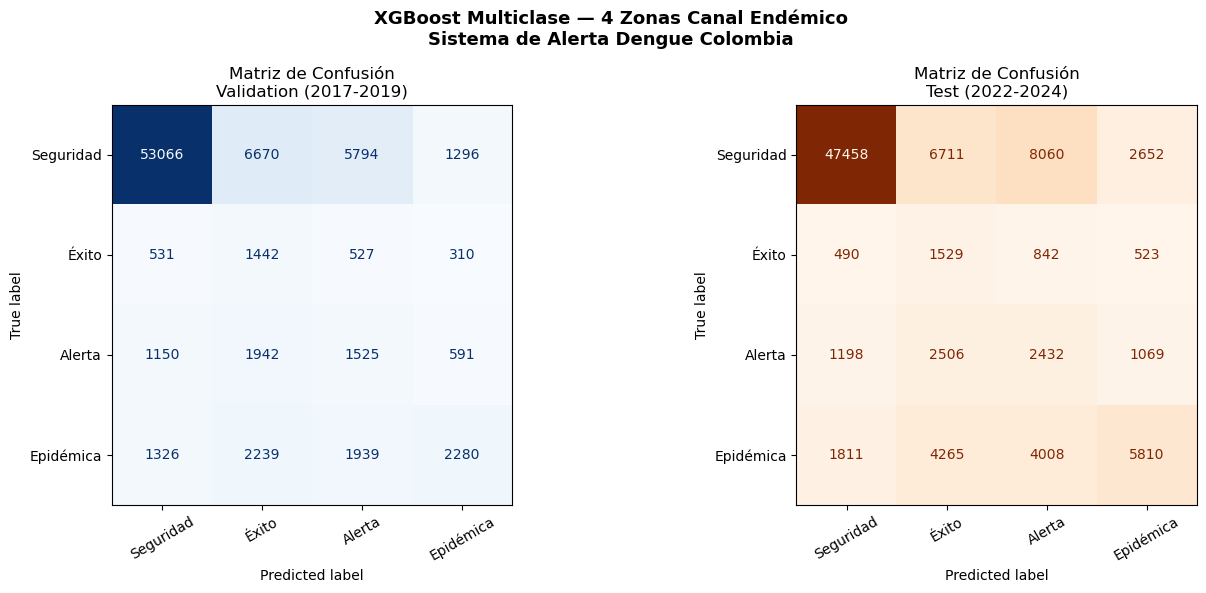


=== COMPARACIÓN BINARIO vs MULTICLASE ===
Modelo                         Métrica           Validation         Test
----------------------------------------------------------------------
XGBoost Binario                F2-score               0.678        0.762
XGBoost Multiclase             F1 weighted            0.753        0.683
XGBoost Multiclase             F1 macro               0.407        0.412


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Variable objetivo multiclase
ZONAS = {'seguridad': 0, 'exito': 1, 'alerta': 2, 'epidemica': 3}
df_modelo_sorted['zona_num'] = df_modelo_sorted['zona_canal'].map(ZONAS)

# Redividir
df_tr_m  = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2009,2017))].copy()
df_val_m = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2017,2020))].copy()
df_te_m  = df_modelo_sorted[df_modelo_sorted['anio'].isin([2022,2023,2024])].copy()

df_tr_mc  = df_tr_m.dropna(subset=FEATURES_FINAL + ['zona_num']).copy()
df_val_mc = df_val_m.dropna(subset=FEATURES_FINAL + ['zona_num']).copy()
df_te_mc  = df_te_m.dropna(subset=FEATURES_FINAL + ['zona_num']).copy()

X_tr_m  = df_tr_mc[FEATURES_FINAL];  y_tr_m  = df_tr_mc['zona_num'].astype(int)
X_val_m = df_val_mc[FEATURES_FINAL]; y_val_m = df_val_mc['zona_num'].astype(int)
X_te_m  = df_te_mc[FEATURES_FINAL];  y_te_m  = df_te_mc['zona_num'].astype(int)

print('Distribución clases TRAIN:')
dist = y_tr_m.value_counts().sort_index()
for k, v in dist.items():
    zona = [z for z,n in ZONAS.items() if n==k][0]
    print(f'  {k} - {zona:<12}: {v:,} ({v/len(y_tr_m)*100:.1f}%)')

# Pesos inversamente proporcionales al tamaño de clase
from collections import Counter
conteo = Counter(y_tr_m)
total  = len(y_tr_m)
pesos  = {k: total / (len(conteo) * v) for k, v in conteo.items()}
print(f'\nPesos de clase: {pesos}')

# Entrenar XGBoost multiclase
xgb_multi = xgb.XGBClassifier(
    n_estimators    = 300,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    objective       = 'multi:softprob',
    num_class       = 4,
    eval_metric     = 'mlogloss',
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0
)

# Aplicar pesos por muestra
sample_weights = np.array([pesos[y] for y in y_tr_m])
print('\nEntrenando XGBoost multiclase...')
xgb_multi.fit(X_tr_m, y_tr_m, sample_weight=sample_weights)
print('✅ Modelo entrenado')

# Evaluar en validation y test
NOMBRES_ZONAS = ['Seguridad', 'Éxito', 'Alerta', 'Epidémica']

for nombre, X, y_r in [('VALIDATION (2017-2019)', X_val_m, y_val_m),
                        ('TEST (2022-2024)',        X_te_m,  y_te_m)]:
    y_pred = xgb_multi.predict(X)
    print(f'\n=== {nombre} ===')
    print(classification_report(y_r, y_pred,
                                 target_names=NOMBRES_ZONAS,
                                 digits=3, zero_division=0))

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XGBoost Multiclase — 4 Zonas Canal Endémico\n'
             'Sistema de Alerta Dengue Colombia',
             fontsize=13, fontweight='bold')

for ax, (X, y_r, titulo, cmap) in zip(axes, [
    (X_val_m, y_val_m, 'Validation (2017-2019)', 'Blues'),
    (X_te_m,  y_te_m,  'Test (2022-2024)',       'Oranges')
]):
    y_pred = xgb_multi.predict(X)
    cm = confusion_matrix(y_r, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=NOMBRES_ZONAS).plot(
        ax=ax, colorbar=False, cmap=cmap, xticks_rotation=30)
    ax.set_title(f'Matriz de Confusión\n{titulo}')

plt.tight_layout()
plt.savefig('xgb_multiclase_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparación binario vs multiclase
from sklearn.metrics import f1_score
print('\n=== COMPARACIÓN BINARIO vs MULTICLASE ===')
print(f'{"Modelo":<30} {"Métrica":<15} {"Validation":>12} {"Test":>12}')
print('-'*70)

# Binario
yp_val_bin = (mejor_modelo.predict_proba(X_val)[:,1] >= UMBRAL_OPT).astype(int)
yp_te_bin  = (mejor_modelo.predict_proba(X_te)[:,1]  >= UMBRAL_OPT).astype(int)
f2_val_bin = fbeta_score(y_val, yp_val_bin, beta=2)
f2_te_bin  = fbeta_score(y_te,  yp_te_bin,  beta=2)
print(f'{"XGBoost Binario":<30} {"F2-score":<15} {f2_val_bin:>12.3f} {f2_te_bin:>12.3f}')

# Multiclase (weighted F1)
yp_val_mul = xgb_multi.predict(X_val_m)
yp_te_mul  = xgb_multi.predict(X_te_m)
f1_val_mul = f1_score(y_val_m, yp_val_mul, average='weighted', zero_division=0)
f1_te_mul  = f1_score(y_te_m,  yp_te_mul,  average='weighted', zero_division=0)
f1_val_mac = f1_score(y_val_m, yp_val_mul, average='macro',    zero_division=0)
f1_te_mac  = f1_score(y_te_m,  yp_te_mul,  average='macro',    zero_division=0)
print(f'{"XGBoost Multiclase":<30} {"F1 weighted":<15} {f1_val_mul:>12.3f} {f1_te_mul:>12.3f}')
print(f'{"XGBoost Multiclase":<30} {"F1 macro":<15} {f1_val_mac:>12.3f} {f1_te_mac:>12.3f}')

## Paso 13 — Índice ENSO (ONI) desde NOAA

In [13]:
# ── Descargar índice ONI (ENSO) desde NOAA ────────────────────────────────────
import pandas as pd
import numpy as np
import requests
import io

# URL oficial NOAA — índice ONI histórico
URL_ONI = 'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt'

resp = requests.get(URL_ONI, timeout=30)
resp.raise_for_status()

print('Primeras líneas del archivo:')
print(resp.text[:500])

# ── Parsear y procesar índice ONI ─────────────────────────────────────────────
from io import StringIO

# Parsear el archivo
df_oni_raw = pd.read_csv(
    StringIO(resp.text),
    sep=r'\s+',
    header=0,
    names=['temporada','anio','temp_total','oni']
)

print(f'ONI descargado: {len(df_oni_raw)} registros')
print(f'Años: {df_oni_raw["anio"].min()} - {df_oni_raw["anio"].max()}')
print(df_oni_raw.head(10).to_string())

# ── Convertir ONI trimestral a semanas epidemiológicas ────────────────────────

# Mapeo temporada → meses centrales
TEMPORADA_MES = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,
    'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}

df_oni_raw['mes'] = df_oni_raw['temporada'].map(TEMPORADA_MES)
df_oni_raw['anio'] = df_oni_raw['anio'].astype(int)

# Clasificar fase ENSO según umbrales estándar NOAA
# El Niño: ONI >= +0.5 por 5 temporadas consecutivas
# La Niña: ONI <= -0.5
def clasificar_enso(oni):
    if oni >= 1.5:  return 3   # El Niño fuerte
    elif oni >= 0.5: return 2  # El Niño moderado
    elif oni <= -1.5: return -3 # La Niña fuerte
    elif oni <= -0.5: return -2 # La Niña moderada
    else:            return 0   # Neutro

df_oni_raw['fase_enso'] = df_oni_raw['oni'].apply(clasificar_enso)

# Expandir a semanas: asignar ONI a cada semana del mes central
registros = []
for _, row in df_oni_raw.iterrows():
    anio = row['anio']
    mes  = row['mes']
    # Semanas aproximadas que caen en ese mes (cada mes ~4.3 semanas)
    sem_inicio = int((mes - 1) * 52/12) + 1
    sem_fin    = int(mes * 52/12) + 1
    for sem in range(sem_inicio, sem_fin):
        if 1 <= sem <= 52:
            registros.append({
                'anio'      : anio,
                'semana_epi': sem,
                'oni'       : row['oni'],
                'fase_enso' : row['fase_enso']
            })

df_oni = pd.DataFrame(registros).drop_duplicates(['anio','semana_epi'])

# Filtrar años relevantes
df_oni = df_oni[df_oni['anio'].isin(list(range(2009,2020)) + [2022,2023,2024])]

print(f'ONI semanal: {len(df_oni):,} registros')
print(f'Años: {sorted(df_oni["anio"].unique())}')
print(f'\nDistribución fases ENSO:')
fases = {3:'El Niño fuerte', 2:'El Niño moderado',
         0:'Neutro', -2:'La Niña moderada', -3:'La Niña fuerte'}
print(df_oni['fase_enso'].map(fases).value_counts().to_string())
print(f'\nEjemplo 2016 (año El Niño fuerte):')
print(df_oni[df_oni['anio']==2016][['anio','semana_epi','oni','fase_enso']].head(5).to_string())

# ── Cruzar ONI con dataset y agregar variables adicionales ────────────────────

# 1. Cruce ONI
df_modelo_sorted = df_modelo_sorted.merge(
    df_oni[['anio','semana_epi','oni','fase_enso']],
    on=['anio','semana_epi'], how='left'
)
df_modelo_sorted['oni']        = df_modelo_sorted['oni'].fillna(0)
df_modelo_sorted['fase_enso']  = df_modelo_sorted['fase_enso'].fillna(0)

# 2. Evento cálido-húmedo (interacción temperatura x humedad)
temp_p75 = df_modelo_sorted['temp_media_c'].quantile(0.75)
hum_p75  = df_modelo_sorted['humedad_pct'].quantile(0.75)
df_modelo_sorted['evento_calido_humedo'] = (
    (df_modelo_sorted['temp_media_c'] > temp_p75) &
    (df_modelo_sorted['humedad_pct']  > hum_p75)
).astype(int)

# 3. Extremos hidrológicos
precip_p10 = df_modelo_sorted['precip_acum8'].quantile(0.10)
precip_p90 = df_modelo_sorted['precip_acum8'].quantile(0.90)
df_modelo_sorted['sequia']        = (df_modelo_sorted['precip_acum8'] < precip_p10).astype(int)
df_modelo_sorted['lluvia_extrema'] = (df_modelo_sorted['precip_acum8'] > precip_p90).astype(int)

# Verificar
print('Variables ENSO y climáticas agregadas:')
print(f'  ONI promedio 2016 (El Niño): {df_modelo_sorted[df_modelo_sorted["anio"]==2016]["oni"].mean():.2f}')
print(f'  ONI promedio 2011 (La Niña): {df_modelo_sorted[df_modelo_sorted["anio"]==2011]["oni"].mean():.2f}')
print(f'  % semanas evento cálido-húmedo: {df_modelo_sorted["evento_calido_humedo"].mean()*100:.1f}%')
print(f'  % semanas sequía             : {df_modelo_sorted["sequia"].mean()*100:.1f}%')
print(f'  % semanas lluvia extrema     : {df_modelo_sorted["lluvia_extrema"].mean()*100:.1f}%')

# ── Actualizar FEATURES_FINAL con nuevas variables ────────────────────────────
FEATURES_FINAL_V2 = FEATURES_FINAL + [
    'oni', 'fase_enso',
    'evento_calido_humedo',
    'sequia', 'lluvia_extrema'
]

# Redividir
df_tr_c2  = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2009,2017))].dropna(subset=FEATURES_FINAL_V2 + ['alerta']).copy()
df_val_c2 = df_modelo_sorted[df_modelo_sorted['anio'].isin(range(2017,2020))].dropna(subset=FEATURES_FINAL_V2 + ['alerta']).copy()
df_te_c2  = df_modelo_sorted[df_modelo_sorted['anio'].isin([2022,2023,2024])].dropna(subset=FEATURES_FINAL_V2 + ['alerta']).copy()

X_tr2  = df_tr_c2[FEATURES_FINAL_V2];  y_tr2  = df_tr_c2['alerta'].astype(int)
X_val2 = df_val_c2[FEATURES_FINAL_V2]; y_val2 = df_val_c2['alerta'].astype(int)
X_te2  = df_te_c2[FEATURES_FINAL_V2];  y_te2  = df_te_c2['alerta'].astype(int)

print(f'\nTRAIN      : {len(X_tr2):,} | alerta: {y_tr2.mean()*100:.1f}%')
print(f'VALIDATION : {len(X_val2):,} | alerta: {y_val2.mean()*100:.1f}%')
print(f'TEST       : {len(X_te2):,} | alerta: {y_te2.mean()*100:.1f}%')
print(f'Features   : {len(FEATURES_FINAL_V2)} (antes: {len(FEATURES_FINAL)})')

# ── Reentrenar XGBoost con nuevas variables ───────────────────────────────────
print('\nEntrenando XGBoost v3 (con ENSO + interacciones)...')
xgb_v3 = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=5,
    eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
)
xgb_v3.fit(X_tr2, y_tr2)

y_prob_v3 = xgb_v3.predict_proba(X_val2)[:, 1]
y_pred_v3 = (y_prob_v3 >= UMBRAL_OPT).astype(int)

print('\n=== COMPARACIÓN VALIDATION ===')
print(f'{"Modelo":<25} {"F2":>6} {"AUC":>6} {"Recall":>8} {"Precision":>10}')
print('-'*55)

# Versión anterior
y_prob_prev = mejor_modelo.predict_proba(X_val)[:, 1]
y_pred_prev = (y_prob_prev >= UMBRAL_OPT).astype(int)
print(f'{"XGBoost sin ENSO":<25} '
      f'{fbeta_score(y_val, y_pred_prev, beta=2):>6.3f} '
      f'{roc_auc_score(y_val, y_prob_prev):>6.3f} '
      f'{recall_score(y_val, y_pred_prev, zero_division=0):>8.3f} '
      f'{precision_score(y_val, y_pred_prev, zero_division=0):>10.3f}')

# Nueva versión
print(f'{"XGBoost con ENSO":<25} '
      f'{fbeta_score(y_val2, y_pred_v3, beta=2):>6.3f} '
      f'{roc_auc_score(y_val2, y_prob_v3):>6.3f} '
      f'{recall_score(y_val2, y_pred_v3, zero_division=0):>8.3f} '
      f'{precision_score(y_val2, y_pred_v3, zero_division=0):>10.3f}')

print('\nImportancia nuevas variables:')
imp_v3 = pd.Series(xgb_v3.feature_importances_, index=FEATURES_FINAL_V2)
nuevas = ['oni','fase_enso','evento_calido_humedo','sequia','lluvia_extrema']
print(imp_v3[nuevas].sort_values(ascending=False).round(4).to_string())

Primeras líneas del archivo:
 SEAS  YR   TOTAL   ANOM
  DJF 1950  24.72  -1.53
  JFM 1950  25.17  -1.34
  FMA 1950  25.75  -1.16
  MAM 1950  26.12  -1.18
  AMJ 1950  26.32  -1.07
  MJJ 1950  26.31  -0.85
  JJA 1950  26.21  -0.54
  JAS 1950  25.96  -0.42
  ASO 1950  25.76  -0.39
  SON 1950  25.63  -0.44
  OND 1950  25.48  -0.60
  NDJ 1950  25.34  -0.80
  DJF 1951  25.42  -0.82
  JFM 1951  25.96  -0.54
  FMA 1951  26.74  -0.17
  MAM 1951  27.48   0.18
  AMJ 1951  27.75   0.36
  MJJ 1951  27.75   0.58
  JJA 1951  27.44   0.70

ONI descargado: 915 registros
Años: 1950 - 2026
  temporada  anio  temp_total   oni
0       DJF  1950       24.72 -1.53
1       JFM  1950       25.17 -1.34
2       FMA  1950       25.75 -1.16
3       MAM  1950       26.12 -1.18
4       AMJ  1950       26.32 -1.07
5       MJJ  1950       26.31 -0.85
6       JJA  1950       26.21 -0.54
7       JAS  1950       25.96 -0.42
8       ASO  1950       25.76 -0.39
9       SON  1950       25.63 -0.44
ONI semanal: 728 registros

## Paso 14 — Densidad poblacional aproximada (Voronoi)

In [16]:
# ── Densidad poblacional aproximada via área de Voronoi ───────────────────────
# Cada municipio "controla" el área más cercana a su centroide
# Es una aproximación válida cuando no tenemos el shapefile exacto

from scipy.spatial import Voronoi
from shapely.geometry import Polygon, MultiPolygon
import warnings
warnings.filterwarnings('ignore')

# Coordenadas de municipios válidos
df_coords = (df_mun[df_mun['cod_municipio'].isin(municipios_validos)]
             [['cod_municipio','NOM_MPIO','NOM_DPTO','altitud_msnm']]
             .drop_duplicates('cod_municipio')
             .merge(
                 pd.read_csv('https://www.datos.gov.co/api/views/vafm-j2df/rows.csv?accessType=DOWNLOAD',
                             low_memory=False)
                 .assign(cod_municipio=lambda x: x['COD_MPIO'].astype(int).astype(str).str.zfill(5))
                 [['cod_municipio','LATITUD','LONGITUD']],
                 on='cod_municipio', how='left'
             )
             .dropna(subset=['LATITUD','LONGITUD'])
)

# Convertir grados a km aproximados (Colombia ~4°N, 1°lat≈111km, 1°lon≈110km)
df_coords['lat_km'] = df_coords['LATITUD']  * 111.0
df_coords['lon_km'] = df_coords['LONGITUD'] * 110.0

# Calcular polígonos de Voronoi
coords_km = df_coords[['lon_km','lat_km']].values

# Agregar puntos infinitos en los bordes para que Voronoi sea finito
from scipy.spatial import ConvexHull
hull = ConvexHull(coords_km)
border_points = coords_km[hull.vertices] * 3  # puntos lejanos

all_points = np.vstack([coords_km, border_points])
vor = Voronoi(all_points)

# Calcular área de cada región de Voronoi en km²
areas_km2 = []
for i, region_idx in enumerate(vor.point_region[:len(df_coords)]):
    region = vor.regions[region_idx]
    if -1 not in region and len(region) > 0:
        vertices = vor.vertices[region]
        poly = Polygon(vertices)
        areas_km2.append(poly.area)
    else:
        areas_km2.append(np.nan)

df_coords['area_km2'] = areas_km2

# Limpiar áreas extremas (outliers por bordes del Voronoi)
p95 = df_coords['area_km2'].quantile(0.95)
df_coords['area_km2'] = df_coords['area_km2'].clip(upper=p95)

print(f'Municipios con área calculada: {df_coords["area_km2"].notna().sum()}')
print(f'\nEstadísticas área (km²):')
print(df_coords['area_km2'].describe().round(1).to_string())
print(f'\nEjemplos:')
print(df_coords[['cod_municipio','NOM_MPIO','area_km2']].head(10).to_string())

Municipios con área calculada: 647

Estadísticas área (km²):
count      647.0
mean      1654.7
std       2696.4
min         46.6
25%        326.3
50%        725.0
75%       1454.6
max      11568.3

Ejemplos:
  cod_municipio               NOM_MPIO     area_km2
0         05001               MEDELLÍN   196.162927
1         05002              ABEJORRAL   679.278964
2         05030                  AMAGÁ   136.228213
3         05034                  ANDES   602.205751
4         05040                  ANORÍ  2149.251225
5         05042  SANTA FÉ DE ANTIOQUIA   900.717685
6         05044                   ANZÁ   652.574490
7         05045               APARTADÓ  1271.909994
8         05051              ARBOLETES   595.416728
9         05059                ARMENIA   250.285903


In [17]:
# ── Calcular densidad poblacional y agregar al modelo ─────────────────────────

# Población por municipio (usar año 2016 como referencia para todos)
pob_2016 = (df_mun[df_mun['anio']==2016]
            .groupby('cod_municipio')['poblacion'].first()
            .reset_index()
            .rename(columns={'poblacion':'pob_ref'}))

df_coords = df_coords.merge(pob_2016, on='cod_municipio', how='left')
df_coords['densidad_hab_km2'] = df_coords['pob_ref'] / df_coords['area_km2']

print('Top 10 municipios más densos:')
print(df_coords.nlargest(10,'densidad_hab_km2')[
    ['cod_municipio','NOM_MPIO','NOM_DPTO','pob_ref','area_km2','densidad_hab_km2']
].round(1).to_string())

print('\nTop 10 municipios menos densos:')
print(df_coords.nsmallest(10,'densidad_hab_km2')[
    ['cod_municipio','NOM_MPIO','NOM_DPTO','pob_ref','area_km2','densidad_hab_km2']
].round(1).to_string())

# Agregar al modelo
df_modelo_sorted = df_modelo_sorted.merge(
    df_coords[['cod_municipio','area_km2','densidad_hab_km2']],
    on='cod_municipio', how='left'
)

print(f'\nMunicipios con densidad: {df_modelo_sorted["densidad_hab_km2"].notna().sum():,}')
print(f'Sin densidad           : {df_modelo_sorted["densidad_hab_km2"].isna().sum():,}')

Top 10 municipios más densos:
    cod_municipio     NOM_MPIO         NOM_DPTO    pob_ref  area_km2  densidad_hab_km2
0           05001     MEDELLÍN        ANTIOQUIA  2351077.0     196.2           11985.3
33          05360       ITAGÜÍ        ANTIOQUIA   266257.0      71.2            3741.9
570         76001         CALI  VALLE DEL CAUCA  2195915.0     705.1            3114.3
442         66001      PEREIRA        RISARALDA   459033.0     186.5            2461.0
432         63001      ARMENIA          QUINDÍO   289151.0     123.6            2338.9
11          05088        BELLO        ANTIOQUIA   499621.0     233.6            2138.5
51          05631     SABANETA        ANTIOQUIA    77966.0      46.6            1673.1
84          08433      MALAMBO        ATLÁNTICO   121589.0      76.0            1598.8
454         68001  BUCARAMANGA        SANTANDER   562123.0     372.8            1507.9
28          05266     ENVIGADO        ANTIOQUIA   218805.0     189.2            1156.7

Top 10 munic

## Paso 15 — Evaluación final en TEST

RESULTADO FINAL — TEST (2022-2024)
Sistema de Alerta Temprana Dengue Colombia
Modelo: XGBoost | Canal Endémico Municipal
              precision    recall  f1-score   support

      NORMAL      0.942     0.718     0.815     68265
      ALERTA      0.510     0.869     0.643     23099

    accuracy                          0.756     91364
   macro avg      0.726     0.793     0.729     91364
weighted avg      0.833     0.756     0.771     91364

F2-score : 0.762
AUC-ROC  : 0.873


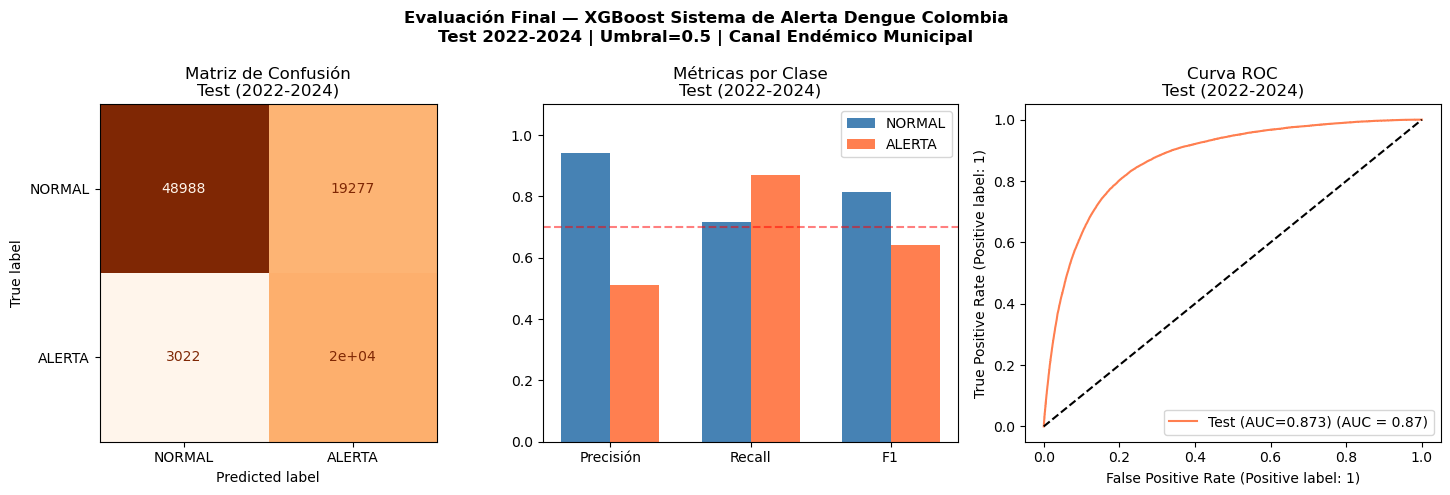

In [18]:
# ── EVALUACIÓN FINAL EN TEST — modelo v1 ─────────────────────────────────────

UMBRAL_FINAL = 0.5

y_prob_test = mejor_modelo.predict_proba(X_te)[:, 1]
y_pred_test = (y_prob_test >= UMBRAL_FINAL).astype(int)

print('='*60)
print('RESULTADO FINAL — TEST (2022-2024)')
print('Sistema de Alerta Temprana Dengue Colombia')
print('Modelo: XGBoost | Canal Endémico Municipal')
print('='*60)
print(classification_report(y_te, y_pred_test,
                             target_names=['NORMAL','ALERTA'], digits=3))
print(f'F2-score : {fbeta_score(y_te, y_pred_test, beta=2):.3f}')
print(f'AUC-ROC  : {roc_auc_score(y_te, y_prob_test):.3f}')

# Gráficas finales
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Evaluación Final — XGBoost Sistema de Alerta Dengue Colombia\n'
             f'Test 2022-2024 | Umbral={UMBRAL_FINAL} | Canal Endémico Municipal',
             fontsize=12, fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred_test),
    display_labels=['NORMAL','ALERTA']
).plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Matriz de Confusión\nTest (2022-2024)')

prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred_test)
x = np.arange(3); w = 0.35
axes[1].bar(x-w/2, [prec[0],rec[0],f1[0]], w, label='NORMAL', color='steelblue')
axes[1].bar(x+w/2, [prec[1],rec[1],f1[1]], w, label='ALERTA', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Precisión','Recall','F1'])
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Métricas por Clase\nTest (2022-2024)')
axes[1].legend()
axes[1].axhline(0.7, color='red', linestyle='--', alpha=0.5, label='Meta 0.7')

RocCurveDisplay.from_predictions(
    y_te, y_prob_test, ax=axes[2],
    name=f'Test (AUC={roc_auc_score(y_te, y_prob_test):.3f})',
    color='coral')
axes[2].plot([0,1],[0,1],'k--')
axes[2].set_title('Curva ROC\nTest (2022-2024)')

plt.tight_layout()
plt.savefig('resultado_final_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 16 — Experimento: Horizonte de predicción (1–4 semanas)

Evaluamos cómo cambian las métricas cuando el modelo predice el estado de alerta
con 1, 2, 3 o 4 semanas de anticipación.

**Diseño:** La variable objetivo se desplaza H semanas hacia adelante respecto
a las features disponibles hoy. El modelo se entrena con 2009–2016 y se evalúa
**únicamente en el conjunto de TEST (2022–2024)**.

**Motivación:** El Ministerio de Salud y las Secretarías Departamentales
necesitan suficiente anticipación para activar protocolos de control vectorial
(fumigación, eliminación de criaderos). Según Chan & Johansson (2012), el ciclo
completo mosquito→caso toma ~3 semanas, y la activación de un protocolo de
respuesta toma 1–2 semanas adicionales, sugiriendo un horizonte mínimo accionable
de 4 semanas.


Horizonte H=1 semana(s)...
  Train alerta: 20.7% (225,492 filas)
  Test  alerta: 25.4% (90,731 filas)
  F2=0.716 | AUC=0.835 | Recall=0.812 | Precision=0.486

Horizonte H=2 semana(s)...
  Train alerta: 20.7% (225,492 filas)
  Test  alerta: 25.6% (90,098 filas)
  F2=0.687 | AUC=0.809 | Recall=0.779 | Precision=0.467

Horizonte H=3 semana(s)...
  Train alerta: 20.7% (225,492 filas)
  Test  alerta: 25.7% (89,465 filas)
  F2=0.672 | AUC=0.793 | Recall=0.761 | Precision=0.458

Horizonte H=4 semana(s)...
  Train alerta: 20.7% (225,492 filas)
  Test  alerta: 25.9% (88,832 filas)
  F2=0.657 | AUC=0.778 | Recall=0.747 | Precision=0.444

IMPACTO DEL HORIZONTE DE PREDICCIÓN — TEST (2022-2024)
 Horizonte (sem)    F2   AUC  Recall  Precision
               1 0.716 0.835   0.812      0.486
               2 0.687 0.809   0.779      0.467
               3 0.672 0.793   0.761      0.458
               4 0.657 0.778   0.747      0.444


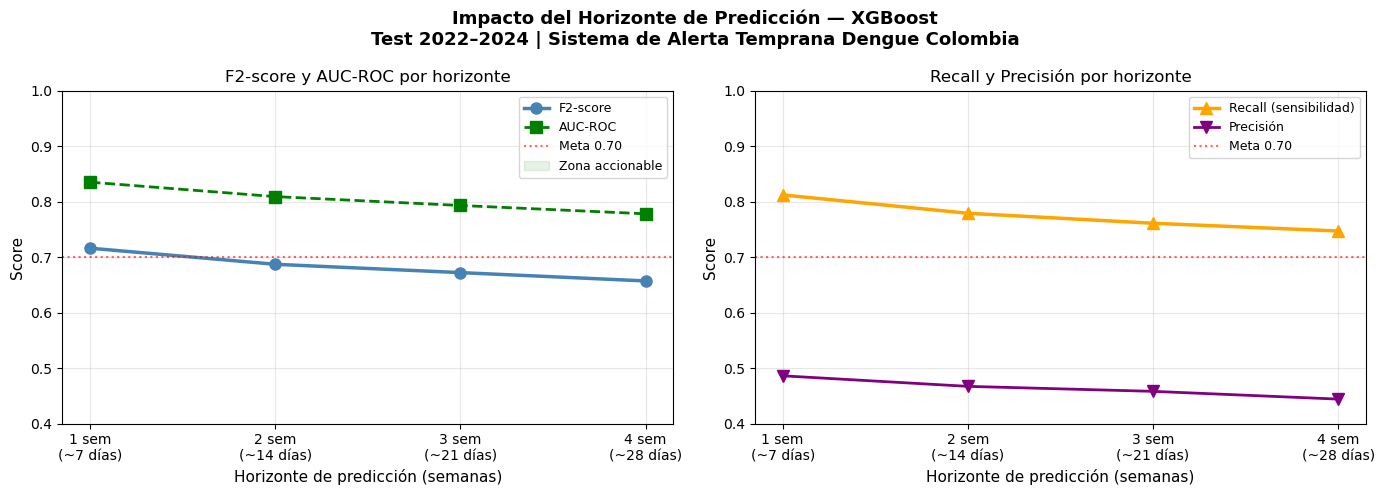

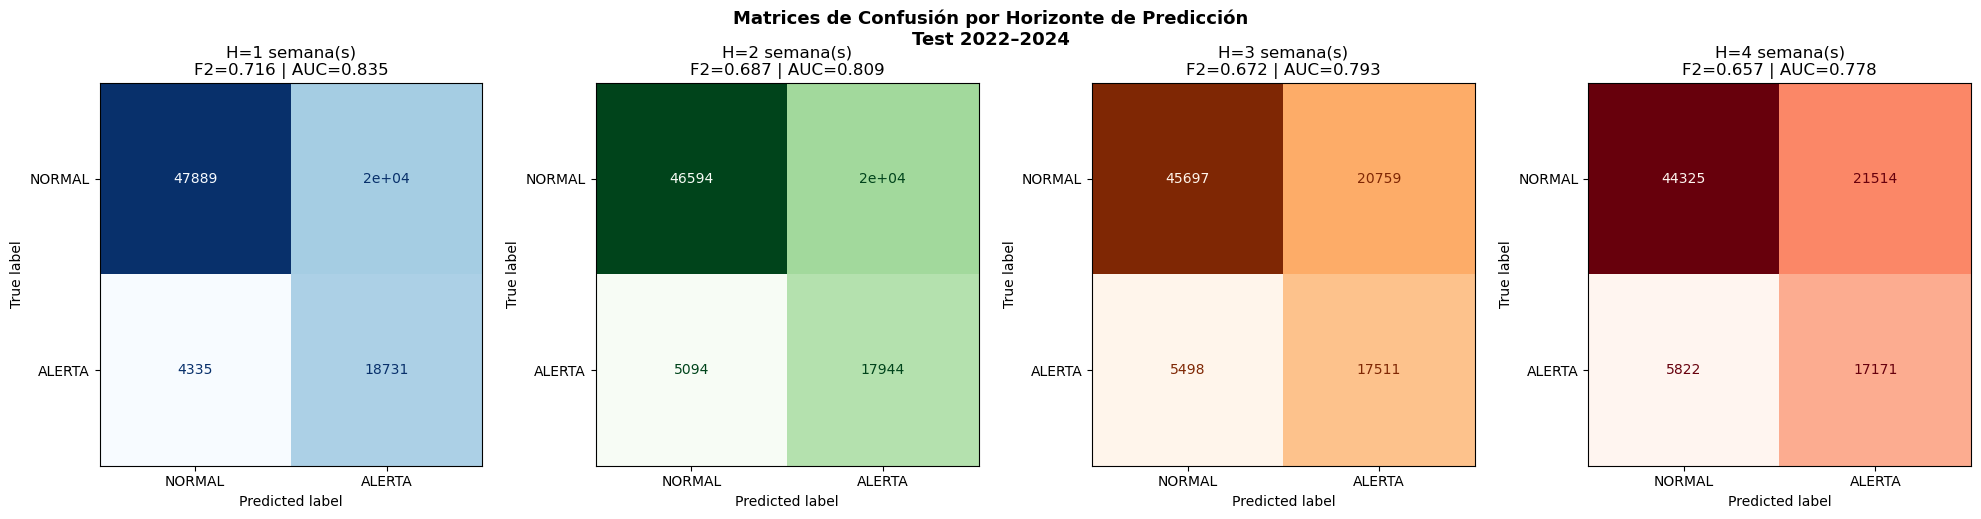


✅ Experimento de horizonte completado
Archivos guardados:
  horizonte_prediccion.png
  horizonte_matrices_confusion.png


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import (fbeta_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              precision_recall_fscore_support)

resultados_horizonte = []
modelos_horizonte    = {}

AÑOS_TRAIN = list(range(2009, 2017))   # 2009-2016 — entrenamiento
AÑOS_TEST  = [2022, 2023, 2024]        # 2022-2024 — evaluación final
# ⚠️ NO se usa validation para este experimento
# El umbral se fija en 0.5 para comparación directa entre horizontes

for H in [1, 2, 3, 4]:
    print(f'\nHorizonte H={H} semana(s)...')

    # Variable objetivo desplazada H semanas hacia adelante
    df_h = df_modelo_sorted.copy()
    df_h['alerta_future'] = (df_h
                             .groupby('cod_municipio')['alerta']
                             .shift(-H))

    df_h = df_h.dropna(subset=FEATURES_FINAL + ['alerta_future']).copy()
    df_h['alerta_future'] = df_h['alerta_future'].astype(int)

    # Train: 2009-2016 | Test: 2022-2024
    df_tr_h = df_h[df_h['anio'].isin(AÑOS_TRAIN)]
    df_te_h = df_h[df_h['anio'].isin(AÑOS_TEST)]

    X_tr_h = df_tr_h[FEATURES_FINAL]; y_tr_h = df_tr_h['alerta_future']
    X_te_h = df_te_h[FEATURES_FINAL]; y_te_h = df_te_h['alerta_future']

    print(f'  Train alerta: {y_tr_h.mean()*100:.1f}% ({len(X_tr_h):,} filas)')
    print(f'  Test  alerta: {y_te_h.mean()*100:.1f}% ({len(X_te_h):,} filas)')

    # Entrenar XGBoost
    modelo_h = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=5,
        eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
    )
    modelo_h.fit(X_tr_h, y_tr_h)
    modelos_horizonte[H] = modelo_h

    # Evaluar en TEST con umbral fijo 0.5
    y_prob_h = modelo_h.predict_proba(X_te_h)[:, 1]
    y_pred_h = (y_prob_h >= 0.5).astype(int)

    f2  = fbeta_score(y_te_h, y_pred_h, beta=2, zero_division=0)
    auc = roc_auc_score(y_te_h, y_prob_h)
    rec = recall_score(y_te_h, y_pred_h, zero_division=0)
    pre = precision_score(y_te_h, y_pred_h, zero_division=0)

    resultados_horizonte.append({
        'Horizonte (sem)': H,
        'F2'     : round(f2,  3),
        'AUC'    : round(auc, 3),
        'Recall' : round(rec, 3),
        'Precision': round(pre, 3),
    })
    print(f'  F2={f2:.3f} | AUC={auc:.3f} | Recall={rec:.3f} | Precision={pre:.3f}')

# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_hor = pd.DataFrame(resultados_horizonte)
print('\n' + '='*60)
print('IMPACTO DEL HORIZONTE DE PREDICCIÓN — TEST (2022-2024)')
print('='*60)
print(df_hor.to_string(index=False))

# ── Gráfica principal ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impacto del Horizonte de Predicción — XGBoost\n'
             'Test 2022–2024 | Sistema de Alerta Temprana Dengue Colombia',
             fontsize=13, fontweight='bold')

x = df_hor['Horizonte (sem)']

# Panel izquierdo: F2 y AUC
axes[0].plot(x, df_hor['F2'],  'o-', color='steelblue', linewidth=2.5,
             markersize=8, label='F2-score')
axes[0].plot(x, df_hor['AUC'], 's--', color='green', linewidth=2,
             markersize=8, label='AUC-ROC')
axes[0].axhline(0.7, color='red', linestyle=':', alpha=0.6, label='Meta 0.70')
axes[0].fill_between(x, df_hor['F2'], 0.7,
                     where=df_hor['F2'] >= 0.7,
                     alpha=0.1, color='green', label='Zona accionable')
axes[0].set_xlabel('Horizonte de predicción (semanas)', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('F2-score y AUC-ROC por horizonte')
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(['1 sem\n(~7 días)', '2 sem\n(~14 días)',
                          '3 sem\n(~21 días)', '4 sem\n(~28 días)'])
axes[0].set_ylim(0.4, 1.0)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel derecho: Recall y Precision
axes[1].plot(x, df_hor['Recall'],    '^-', color='orange', linewidth=2.5,
             markersize=8, label='Recall (sensibilidad)')
axes[1].plot(x, df_hor['Precision'], 'v-', color='purple', linewidth=2,
             markersize=8, label='Precisión')
axes[1].axhline(0.7, color='red', linestyle=':', alpha=0.6, label='Meta 0.70')
axes[1].set_xlabel('Horizonte de predicción (semanas)', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Recall y Precisión por horizonte')
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xticklabels(['1 sem\n(~7 días)', '2 sem\n(~14 días)',
                          '3 sem\n(~21 días)', '4 sem\n(~28 días)'])
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('horizonte_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Matrices de confusión por horizonte ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))
fig2.suptitle('Matrices de Confusión por Horizonte de Predicción\n'
              'Test 2022–2024', fontsize=13, fontweight='bold')

cmaps = ['Blues', 'Greens', 'Oranges', 'Reds']
for i, H in enumerate([1, 2, 3, 4]):
    df_te_h = df_modelo_sorted[
        df_modelo_sorted['anio'].isin(AÑOS_TEST)].copy()
    df_te_h['alerta_future'] = (df_te_h
                                .groupby('cod_municipio')['alerta']
                                .shift(-H))
    df_te_h = df_te_h.dropna(subset=FEATURES_FINAL + ['alerta_future'])
    X_te_h = df_te_h[FEATURES_FINAL]
    y_te_h = df_te_h['alerta_future'].astype(int)

    y_prob = modelos_horizonte[H].predict_proba(X_te_h)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_te_h, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['NORMAL','ALERTA']).plot(
        ax=axes2[i], colorbar=False, cmap=cmaps[i])
    f2  = fbeta_score(y_te_h, y_pred, beta=2, zero_division=0)
    auc = roc_auc_score(y_te_h, y_prob)
    axes2[i].set_title(f'H={H} semana(s)\nF2={f2:.3f} | AUC={auc:.3f}')

plt.tight_layout()
plt.savefig('horizonte_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Experimento de horizonte completado')
print('Archivos guardados:')
print('  horizonte_prediccion.png')
print('  horizonte_matrices_confusion.png')